In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
url = "https://docs.google.com/spreadsheets/d/1XEFg047aSbg3OsEVx9PzmgSxGbCvCidfLiHfsgRS3R0/export?format=csv"
df = pd.read_csv(url)
display(df.head())

,Prefecture Patient Number,City Patient Number,Date Announced,Date Added,Age Bracket,Gender,"Residence City, Prefecture",Detected City,Detected Prefecture,Status,Notes,Source(s),Related Patients,Known Cluster,Deceased,MHLW (Orig) Patient Number,Charter Flight Passenger,Cruise Passenger (Disembarked),Has ID,Prefecture URL (Auto)
0,1,NaN,2020-01-30,2020-01-30,50,M,"Wuhan, China",NaN,Unspecified,Discharged,Japanese lives in China,https://www.mhlw.go.jp/stf/newpage_09531.html,NaN,Charter Flight,NaN,9,1.0,NaN,0.0,NaN
1,2,NaN,2020-02-01,2020-02-01,40,M,Unspecified,NaN,Unspecified,Discharged,NaN,https://www.mhlw.go.jp/stf/newpage_09531.html,3,Charter Flight,NaN,14,1.0,NaN,0.0,NaN
2,3,NaN,2020-02-01,2020-02-01,40,M,China,NaN,Unspecified,Discharged,Japanese lives in China,https://www.mhlw.go.jp/stf/newpage_09531.html,2,Charter Flight,NaN,15,1.0,NaN,0.0,NaN
3,4,Chiba#2,2020-02-01,2020-02-01,40,M,"Wuhan, China",NaN,Chiba,Discharged,Japanese lives in China,https://www.mhlw.go.jp/stf/newpage_09531.html,NaN,Charter Flight,NaN,16,1.0,NaN,2.0,NaN
4,5,ChibaAsymp#1,2020-01-30,2020-02-04,50,F,Chiba,NaN,Chiba,Discharged,NaN,https://www.mhlw.go.jp/stf/newpage_09531.html,NaN,Charter Flight,NaN,18,1.0,NaN,1.0,https://www.mhlw.go.jp/stf/newpage_09531.html


- Vì dữ liệu trên web đã là file csv sẵn nên ta chỉ cần đọc dùng lệnh read_csv là đã thu được dataframe

### a) Liệt kê số ca nhiễm theo từng thành phố (Detected City).

In [7]:
display(df["Detected City"].value_counts())

Detected City
Sapporo          188
Fukuoka City     101
Tonosho          100
Fukuoka city      96
Kyoto City        86
                ... 
Komono             1
Imizu              1
Nanae, Oshima      1
Kami               1
Atami              1
Name: count, Length: 474, dtype: int64

- Ta đếm giá trị theo giá trị cột Detected City thì sẽ thu được số ca nhiễm của 1 thành phố

### b) Liệt kê số ca nhiễm theo độ tuổi, vẽ biểu đồ (sử dụng hàm plot).

<Axes: title={'center': 'Số ca nhiễm theo độ tuổi'}, xlabel='Age Bracket'>

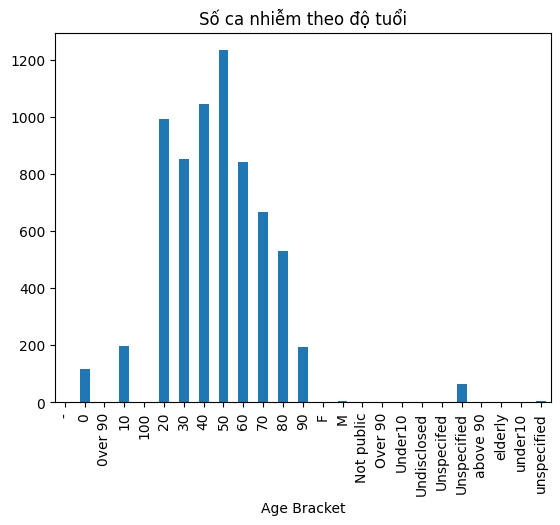

In [8]:
age_counts = df["Age Bracket"].value_counts().sort_index()
age_counts.plot(kind="bar", title="Số ca nhiễm theo độ tuổi")

- ta chỉ cần đếm số lượng mẫu theo giá trị nhóm tuổi thì sẽ thu được số ca nhiễm theo nhóm tuổi rồi chỉ cần dùng plt.bar để vẽ biểu đồ cột biễu diễn

### c) Liệt kê số ca nhiễm tại Hokkaido theo từng ngày. Vẽ biểu đồ. 

Text(0, 0.5, 'Số ca')

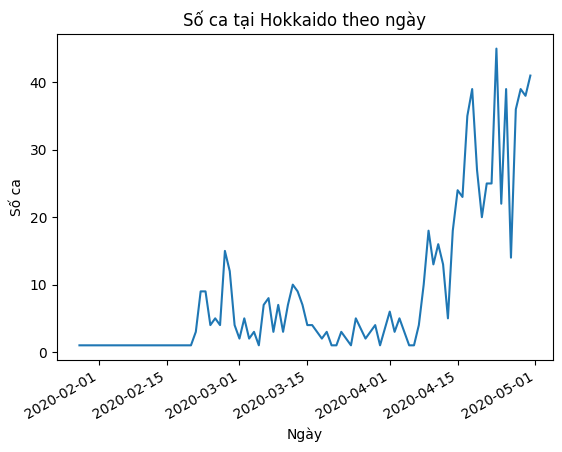

In [ ]:
df["Date Announced"] = pd.to_datetime(df["Date Announced"])
df_Hokkai = df[df["Detected Prefecture"] == "Hokkaido"]
df_Hokkai_ByDay = df_Hokkai["Date Announced"].value_counts().sort_index()
plt.figure()
df_Hokkai_ByDay.plot()
plt.title("Số ca tại Hokkaido theo ngày")
plt.xlabel("Ngày")
plt.ylabel("Số ca")

- Trước tiên ta phải chuyển "Date Announced" sang kiểu dữ liệu date 
- Sau đó lọc ra thành phố Hokkaido 
- Tiếp theo là tính số ca nhiễm dựa trên giá trị ngày 
- Sau đó vẽ biểu đồ là xong